# APO Benchmark — Results Analysis

Dimensions: **accuracy** (test score), **stability** (seed variance), **efficiency** (tokens/calls), **speed** (wall-clock), **generalization** (dev–test gap).

Set `RUN_CUTOFF` to exclude results written before the last clean launch.

In [1]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

OUTPUTS = Path('../outputs/proposal_comparison_3bench_qwen3-4-instruct')
RUN_CUTOFF = None  # e.g. '2026-07-08 22:00' — exclude older files

cutoff_ts = datetime.fromisoformat(RUN_CUTOFF).timestamp() if RUN_CUTOFF else 0

rows = []
for f in sorted(OUTPUTS.rglob('result_*.json')):
    if f.stat().st_mtime < cutoff_ts:
        continue
    rel = f.relative_to(OUTPUTS).parts
    # Layout: [model/]method/task/seed_N/result_*.json
    if len(rel) == 5:
        model, method, task, seed_dir = rel[0], rel[1], rel[2], rel[3]
    else:
        model, method, task, seed_dir = 'default', rel[0], rel[1], rel[2]
    d = json.loads(f.read_text(encoding='utf-8'))
    usage = d.get('llm_usage') or {}
    rows.append({
        'model': model,
        'method': method,
        'task': task.replace('bbh_', ''),
        'seed': int(seed_dir.replace('seed_', '')),
        'dev': d.get('best_score', 0.0),
        'test': d.get('test_score', 0.0),
        'time_s': d.get('total_time', 0.0),
        'calls': usage.get('total_calls', 0),
        'tokens_in': usage.get('total_input_tokens', 0),
        'tokens_out': usage.get('total_output_tokens', 0),
        'tokens': usage.get('total_tokens', 0),
        'iters': d.get('num_iterations', 0),
        'empty_prompt': d.get('best_prompt', '') == '',
        'mtime': datetime.fromtimestamp(f.stat().st_mtime),
    })

df = pd.DataFrame(rows)
if len(df) and df['empty_prompt'].any():
    print(f"WARNING: {int(df['empty_prompt'].sum())} runs have empty best_prompt (stripping-bug era) — set RUN_CUTOFF")
print(f'{len(df)} runs | methods={sorted(df.method.unique())} | tasks={sorted(df.task.unique())}')
print(f'written {df.mtime.min()} → {df.mtime.max()}')

# Completeness check: every method×task should have the same number of seeds
counts = df.pivot_table(index='task', columns='method', values='seed', aggfunc='count')
counts = counts.reindex(index=sorted(df.task.unique()), columns=sorted(df.method.unique()))
expected = int(counts.max().max())
inc = counts.fillna(-1).stack()
inc = inc[inc < expected]
if len(inc):
    print(f'\nINCOMPLETE cells (expected {expected} seeds; -1 = no runs at all):')
    print(inc.astype(int).to_string())
df.head(3)

142 runs | methods=['apex_v1', 'apex_v2', 'baseline', 'capo', 'gaapo', 'gspe', 'see', 'swift_v1', 'swift_v2'] | tasks=['causal_judgement', 'disambiguation_qa', 'formal_fallacies', 'gsm8k', 'humaneval', 'hyperbaton']
written 2026-07-10 09:05:48.194128 → 2026-07-11 00:01:33.217391

INCOMPLETE cells (expected 3 seeds; -1 = no runs at all):
task       method  
gsm8k      apex_v2    -1
           capo       -1
           swift_v2    2
humaneval  apex_v1     2
           apex_v2    -1
           capo       -1
           gspe       -1
           swift_v2   -1


,model,method,task,seed,dev,test,time_s,calls,tokens_in,tokens_out,tokens,iters,empty_prompt,mtime
0,default,apex_v1,causal_judgement,123,0.68,0.582609,469.46,621,1151134,16919,1168053,5,False,2026-07-10 09:06:16.548965
1,default,apex_v1,causal_judgement,42,0.68,0.678261,485.48,706,1176384,18592,1194976,5,False,2026-07-10 09:06:15.618966
2,default,apex_v1,causal_judgement,7,0.72,0.600000,489.56,496,1084110,16359,1100469,5,False,2026-07-10 09:06:14.864348


## 1. Accuracy — test score (mean ± std across seeds)

In [2]:
agg = df.groupby(['method', 'task'])['test'].agg(['mean', 'std', 'count']).reset_index()
agg['std'] = agg['std'].fillna(0.0)
agg['fmt'] = agg.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)

pivot = agg.pivot(index='task', columns='method', values='fmt')
macro = df.groupby('method')['test'].mean()
pivot.loc['** macro avg **'] = {m: f'{macro[m]:.3f}' for m in pivot.columns}
print('Test score (mean ± std over seeds)')
pivot

Test score (mean ± std over seeds)


method,apex_v1,apex_v2,baseline,capo,gaapo,gspe,see,swift_v1,swift_v2
task,,,,,,,,,
causal_judgement,0.620 ± 0.051,0.626 ± 0.023,0.121 ± 0.012,0.606 ± 0.027,0.626 ± 0.030,0.577 ± 0.027,0.594 ± 0.013,0.626 ± 0.009,0.603 ± 0.013
disambiguation_qa,0.571 ± 0.118,0.539 ± 0.077,0.630 ± 0.036,0.614 ± 0.039,0.591 ± 0.035,0.536 ± 0.028,0.583 ± 0.040,0.606 ± 0.035,0.591 ± 0.053
formal_fallacies,0.652 ± 0.009,0.638 ± 0.022,0.290 ± 0.017,0.658 ± 0.031,0.675 ± 0.018,0.641 ± 0.028,0.638 ± 0.036,0.646 ± 0.041,0.667 ± 0.035
gsm8k,0.812 ± 0.043,NaN,0.460 ± 0.000,NaN,0.853 ± 0.061,0.919 ± 0.013,0.837 ± 0.006,0.832 ± 0.040,0.930 ± 0.012
humaneval,0.874 ± 0.031,NaN,0.667 ± 0.000,NaN,0.778 ± 0.017,NaN,0.778 ± 0.017,0.875 ± 0.018,NaN
hyperbaton,0.878 ± 0.023,0.846 ± 0.018,0.677 ± 0.042,0.829 ± 0.056,0.855 ± 0.028,0.855 ± 0.053,0.878 ± 0.023,0.861 ± 0.023,0.852 ± 0.009
** macro avg **,0.726,0.662,0.474,0.677,0.730,0.706,0.718,0.741,0.714


## 2. Per-task best method — std-aware

With 3 seeds a raw argmax on the mean is fragile: it ignores variance and breaks exact ties arbitrarily. This cell:

1. Picks the winner by **lower confidence bound** $LCB = \bar{x} - s/\sqrt{n}$ — among methods with similar means, the more *reliable* one wins;
2. Reports exact **co-winners** explicitly (equal mean and std);
3. Lists every method whose mean is within one pooled standard error ($SE = \sqrt{s_a^2/n_a + s_b^2/n_b}$) of the top mean as a **statistical tie** — where ties exist, the data cannot support claiming a single winner.

In [3]:
def best_with_ties(task_df):
    g = task_df.groupby('method')['test'].agg(['mean', 'std', 'count'])
    g['std'] = g['std'].fillna(0.0)
    g['lcb'] = g['mean'] - g['std'] / np.sqrt(g['count'])

    top_mean = g['mean'].max()

    # Winner: highest LCB — variance-penalized, so between equal means the
    # lower-std method wins instead of an arbitrary ordering pick.
    winner = g['lcb'].idxmax()
    w = g.loc[winner]

    # Exact co-winners: same mean AND same std as the winner (within fp noise)
    co = [m for m, r in g.iterrows() if m != winner
          and abs(r['mean'] - w['mean']) < 1e-9 and abs(r['std'] - w['std']) < 1e-9]

    # Statistical ties: mean within one pooled SE of the TOP mean
    ties = []
    for m, r in g.iterrows():
        if m == winner or m in co:
            continue
        se = math.sqrt(w['std']**2 / max(w['count'], 1) + r['std']**2 / max(r['count'], 1))
        if top_mean - r['mean'] <= se:
            ties.append(f"{m} ({r['mean']:.3f}±{r['std']:.3f})")

    label = winner if not co else ' = '.join([winner] + co)
    return label, w, ties

records = []
for task, tdf in df.groupby('task'):
    label, w, ties = best_with_ties(tdf)
    records.append({
        'task': task,
        'best (by LCB)': label,
        'test': f"{w['mean']:.3f} ± {w['std']:.3f}",
        'LCB': round(w['lcb'], 3),
        'statistically tied (±1 SE)': ', '.join(ties) if ties else '— (clear winner)',
    })
pd.set_option('display.max_colwidth', 90)
best_table = pd.DataFrame(records).set_index('task')
best_table

,best (by LCB),test,LCB,statistically tied (±1 SE)
task,,,,
causal_judgement,swift_v1,0.626 ± 0.009,0.621,"apex_v1 (0.620±0.051), apex_v2 (0.626±0.023), gaapo (0.626±0.030)"
disambiguation_qa,baseline,0.630 ± 0.036,0.609,"apex_v1 (0.571±0.118), capo (0.614±0.039), swift_v1 (0.606±0.035)"
formal_fallacies,gaapo,0.675 ± 0.018,0.665,"capo (0.658±0.031), swift_v2 (0.667±0.035)"
gsm8k,swift_v2,0.930 ± 0.012,0.922,gspe (0.919±0.013)
humaneval,swift_v1,0.875 ± 0.018,0.865,apex_v1 (0.874±0.031)
hyperbaton,apex_v1 = see,0.878 ± 0.023,0.865,"gspe (0.855±0.053), swift_v1 (0.861±0.023)"


## 2b. Best results per task — top run and its winning prompt

For each task: the single best run (highest test score across all methods and seeds) and the actual optimized prompt it produced. Note the framing difference vs §2: this is "the best prompt we found" (one lucky run), while §2 answers "which method is reliably best" (LCB over seeds) — they can legitimately disagree.

In [4]:
# Best single run per task (highest test score across all methods and seeds)
best_runs_table = (df.loc[df.groupby('task')['test'].idxmax(),
                          ['task', 'method', 'seed', 'dev', 'test', 'calls', 'tokens', 'time_s']]
                     .set_index('task')
                     .sort_values('test', ascending=False))
print('Best run per task')
best_runs_table.round(3)

Best run per task


,method,seed,dev,test,calls,tokens,time_s
task,,,,,,,
gsm8k,swift_v2,123,0.980,0.939,356,637629,2981.300
hyperbaton,gspe,7,0.880,0.913,1108,344824,336.980
humaneval,apex_v1,7,0.891,0.896,539,925442,5048.770
formal_fallacies,swift_v2,42,0.700,0.704,392,976203,449.970
causal_judgement,apex_v1,42,0.680,0.678,706,1194976,485.480
disambiguation_qa,baseline,42,0.609,0.660,123,45942,1.655


In [5]:
# Per-task best run: the winning optimized prompt, verbatim.
# These are the artifacts the whole pipeline exists to produce — worth reading:
# they show WHAT each optimizer discovered (format rules, added exemplars, etc.)
best_runs = df.loc[df.groupby('task')['test'].idxmax()]

for _, r in best_runs.iterrows():
    # Reload the result file to get the prompt text
    seed_dir = f"seed_{r['seed']}"
    base = OUTPUTS if r['model'] == 'default' else OUTPUTS / r['model']
    matches = list((base / r['method']).glob(f"*{r['task']}*/{seed_dir}/result_*.json"))
    prompt = ''
    if matches:
        prompt = json.loads(matches[0].read_text(encoding='utf-8')).get('best_prompt', '')
    print('=' * 78)
    print(f"TASK: {r['task']}  |  {r['method']} seed={r['seed']}  |  "
          f"test={r['test']:.3f} (dev={r['dev']:.3f})")
    print('=' * 78)
    print(prompt if prompt else '[prompt not found]')
    print()

TASK: causal_judgement  |  apex_v1 seed=42  |  test=0.678 (dev=0.680)
Determine whether a typical person would answer "Yes" or "No" to the given question about causation.

Examples:
Input: How would a typical person answer each of the following questions about causation?
Tom works for a demolition company, and today he is demolishing a building by implosion. The building will implode automatically at 5:00 PM if both the safety switch is off and knob A is switched on. At 4:00 PM, the safety switch is off, and knob A is on. At that time, Tom checks to see if knob A is on, and he sees that it's on. So, he does not change the position of knob A at all. Because the building would implode if both the safety switch is off and knob A is switched on, the building implodes at 5:00 PM. Did the building implode because Tom did not change the position of knob A?
Options:
- Yes
- No
Output: Yes

Answer with ONLY the final answer, exactly in the same format as these examples: 'Yes', 'No', 'Yes'. No e

## 3. Cost analysis

Budget per method plus cost-effectiveness. Output tokens are broken out — they dominate real API costs (3–5× input price on most providers). `cost_index` is relative to the cheapest method.

In [6]:
cost = df.groupby('method').agg(
    test_mean=('test', 'mean'),
    calls=('calls', 'mean'),
    tokens_in=('tokens_in', 'mean'),
    tokens_out=('tokens_out', 'mean'),
    tokens=('tokens', 'mean'),
    time_min=('time_s', lambda s: s.mean() / 60),
).round(1)
cost['score_per_100k_tok'] = (cost['test_mean'] / (cost['tokens'] / 100_000)).round(3)
cost['score_per_min'] = (cost['test_mean'] / cost['time_min']).round(3)
cost['cost_index'] = (cost['tokens'] / cost['tokens'].min()).round(2)
cost['test_mean'] = cost['test_mean'].round(3)
cost.sort_values('score_per_100k_tok', ascending=False)

,test_mean,calls,tokens_in,tokens_out,tokens,time_min,score_per_100k_tok,score_per_min,cost_index
method,,,,,,,,,
baseline,0.5,110.8,47080.2,11247.2,58327.3,0.5,0.857,1.000,1.00
gspe,0.7,939.4,483838.2,45403.4,529241.6,18.5,0.132,0.038,9.07
apex_v1,0.7,551.4,715584.8,88250.6,803835.4,21.7,0.087,0.032,13.78
swift_v1,0.7,434.3,737624.8,81484.3,819109.1,20.8,0.085,0.034,14.04
swift_v2,0.7,315.1,785948.8,50284.9,836233.7,12.3,0.084,0.057,14.34
see,0.7,964.7,798514.5,90539.3,889053.8,17.3,0.079,0.040,15.24
apex_v2,0.7,396.8,885507.2,18359.1,903866.2,7.4,0.077,0.095,15.50
gaapo,0.7,2403.4,1106043.5,208785.5,1314829.0,31.0,0.053,0.023,22.54
capo,0.7,1770.6,1312140.2,25538.0,1337678.2,16.4,0.052,0.043,22.93


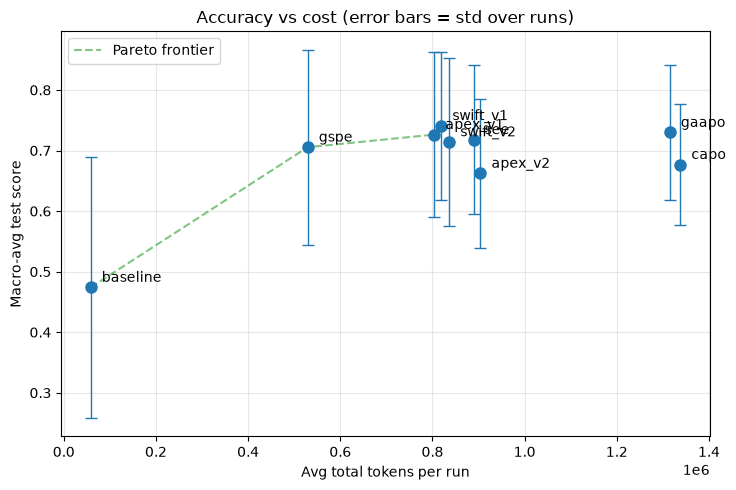

Pareto-efficient: baseline, gspe, apex_v1, swift_v1


In [7]:
# Pareto frontier: methods below/right of the line are dominated —
# something else is both cheaper AND more accurate.
fig, ax = plt.subplots(figsize=(7.5, 5))
pts = df.groupby('method').agg(tokens=('tokens', 'mean'), test=('test', 'mean'),
                               test_std=('test', 'std'))
ax.errorbar(pts['tokens'], pts['test'], yerr=pts['test_std'].fillna(0),
            fmt='o', capsize=4, markersize=8, lw=1)
for m, r in pts.iterrows():
    ax.annotate(m, (r['tokens'], r['test']), textcoords='offset points',
                xytext=(8, 4), fontsize=10)
frontier = []
for m, r in pts.sort_values('tokens').iterrows():
    if not frontier or r['test'] > frontier[-1][1]:
        frontier.append((r['tokens'], r['test'], m))
fx, fy, fm = zip(*frontier)
ax.plot(fx, fy, '--', color='tab:green', alpha=0.6, label='Pareto frontier')
ax.set_xlabel('Avg total tokens per run')
ax.set_ylabel('Macro-avg test score')
ax.set_title('Accuracy vs cost (error bars = std over runs)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Pareto-efficient:', ', '.join(fm))

## 4. Generalization — dev → test gap (positive = overfit to dev)

In [8]:
gap = df.groupby(['method', 'task']).agg(dev=('dev', 'mean'), test=('test', 'mean')).reset_index()
gap['gap'] = (gap['dev'] - gap['test']).round(3)
gap_pivot = gap.pivot(index='task', columns='method', values='gap')
gap_pivot.loc['** mean gap **'] = gap_pivot.mean().round(3)
gap_pivot.style.background_gradient(cmap='RdYlGn_r', axis=None).format('{:.3f}')

method,apex_v1,apex_v2,baseline,capo,gaapo,gspe,see,swift_v1,swift_v2
task,,,,,,,,,
causal_judgement,0.073,0.067,0.097,0.104,0.087,0.103,0.146,0.087,0.097
disambiguation_qa,0.096,0.154,0.080,0.037,0.082,0.017,0.084,0.074,0.082
formal_fallacies,0.088,0.062,-0.087,0.019,0.051,0.079,0.076,0.060,0.040
gsm8k,0.088,nan,0.236,nan,0.039,0.028,0.067,0.068,0.040
humaneval,0.050,nan,0.029,nan,0.050,nan,0.050,0.059,nan
hyperbaton,0.048,0.094,-0.039,0.039,0.065,0.052,0.042,0.066,0.041
** mean gap **,0.074,0.094,0.053,0.050,0.062,0.056,0.078,0.069,0.060


## 5. Stability — seed sensitivity (lower = more reproducible)

In [9]:
per_task_std = df.groupby(['method', 'task'])['test'].std().fillna(0.0)
stability = per_task_std.groupby('method').agg(['mean', 'max']).round(3)
stability.columns = ['avg_std_across_tasks', 'worst_task_std']
stability.sort_values('avg_std_across_tasks')

,avg_std_across_tasks,worst_task_std
method,,
baseline,0.018,0.042
see,0.023,0.040
swift_v2,0.024,0.053
swift_v1,0.028,0.041
gspe,0.030,0.053
gaapo,0.032,0.061
apex_v2,0.035,0.077
capo,0.038,0.056
apex_v1,0.046,0.118


## 6. Head-to-head — paired wins over shared (task, seed) pairs

Pairing removes task difficulty and seed luck. Cell = ROW wins vs COLUMN; † = two-sided sign test p < 0.05.

In [10]:
def sign_test_p(wins, losses):
    n = wins + losses
    if n == 0:
        return 1.0
    k = min(wins, losses)
    p = sum(math.comb(n, i) for i in range(k + 1)) / 2**n
    return min(1.0, 2 * p)

wide = df.pivot_table(index=['task', 'seed'], columns='method', values='test')
methods = sorted(df.method.unique())
h2h = pd.DataFrame(index=methods, columns=methods, dtype=object)
for a in methods:
    for b in methods:
        if a == b:
            h2h.loc[a, b] = '—'
            continue
        pair = wide[[a, b]].dropna()
        wins = int((pair[a] > pair[b]).sum())
        losses = int((pair[a] < pair[b]).sum())
        sig = ' †' if sign_test_p(wins, losses) < 0.05 else ''
        h2h.loc[a, b] = f'{wins}-{losses}{sig}'
print('row beats column (wins-losses; † = sign test p<0.05)')
h2h

row beats column (wins-losses; † = sign test p<0.05)


,apex_v1,apex_v2,baseline,capo,gaapo,gspe,see,swift_v1,swift_v2
apex_v1,—,7-3,9-2,6-4,5-8,7-5,8-5,7-10,7-6
apex_v2,3-7,—,6-2,3-7,3-9,8-3,7-5,4-8,4-4
baseline,2-9,2-6,—,2-6,2-8,2-8,2-8,2-10 †,2-7
capo,4-6,7-3,6-2,—,3-8,8-3,8-4,6-4,5-6
gaapo,8-5,9-3,8-2,8-3,—,10-2 †,8-5,5-7,6-6
gspe,5-7,3-8,8-2,3-8,2-10 †,—,4-8,5-10,2-11 †
see,5-8,5-7,8-2,4-8,5-8,8-4,—,5-7,4-7
swift_v1,10-7,8-4,10-2 †,4-6,7-5,10-5,7-5,—,8-5
swift_v2,6-7,4-4,7-2,6-5,6-6,11-2 †,7-4,5-8,—


## 7. Best method across ALL dimensions

Rank per dimension (1 = best), composite = weighted mean rank. Adjust `WEIGHTS` to your priorities.

In [11]:
WEIGHTS = {
    'accuracy': 0.40,        # macro test (higher better)
    'stability': 0.20,       # avg seed std (lower better)
    'generalization': 0.15,  # dev-test gap (lower better)
    'token_cost': 0.15,      # avg tokens (lower better)
    'speed': 0.10,           # wall-clock (lower better)
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

dims = pd.DataFrame({
    'accuracy': df.groupby('method')['test'].mean(),
    'stability': per_task_std.groupby('method').mean(),
    'generalization': df.groupby('method')['dev'].mean() - df.groupby('method')['test'].mean(),
    'token_cost': df.groupby('method')['tokens'].mean(),
    'speed': df.groupby('method')['time_s'].mean(),
})
ranks = pd.DataFrame({
    'accuracy': dims['accuracy'].rank(ascending=False),
    'stability': dims['stability'].rank(),
    'generalization': dims['generalization'].rank(),
    'token_cost': dims['token_cost'].rank(),
    'speed': dims['speed'].rank(),
})
ranks['composite'] = sum(ranks[d] * w for d, w in WEIGHTS.items())
overall = pd.concat([dims.round(3), ranks.round(2).add_prefix('rank_')], axis=1)
overall = overall.sort_values('rank_composite')
print(f'Overall best considering all dimensions: {overall.index[0]}')
overall

Overall best considering all dimensions: swift_v1


,accuracy,stability,generalization,token_cost,speed,rank_accuracy,rank_stability,rank_generalization,rank_token_cost,rank_speed,rank_composite
method,,,,,,,,,,,
swift_v1,0.741,0.028,0.069,819109.111,1248.956,1.0,4.0,6.0,4.0,7.0,3.40
swift_v2,0.714,0.024,0.061,836233.714,738.117,5.0,3.0,4.0,5.0,3.0,4.25
baseline,0.474,0.018,0.053,58327.333,31.586,9.0,1.0,2.0,1.0,1.0,4.35
see,0.718,0.023,0.077,889053.833,1036.710,4.0,2.0,8.0,6.0,5.0,4.60
gspe,0.706,0.030,0.056,529241.600,1112.005,6.0,5.0,3.0,2.0,6.0,4.75
gaapo,0.730,0.032,0.062,1314829.000,1861.065,2.0,6.0,5.0,8.0,9.0,4.85
apex_v1,0.726,0.046,0.075,803835.353,1304.692,3.0,9.0,7.0,3.0,8.0,5.30
capo,0.677,0.038,0.050,1337678.167,981.782,7.0,8.0,1.0,9.0,4.0,6.30
apex_v2,0.662,0.035,0.094,903866.250,441.388,8.0,7.0,9.0,7.0,2.0,7.20


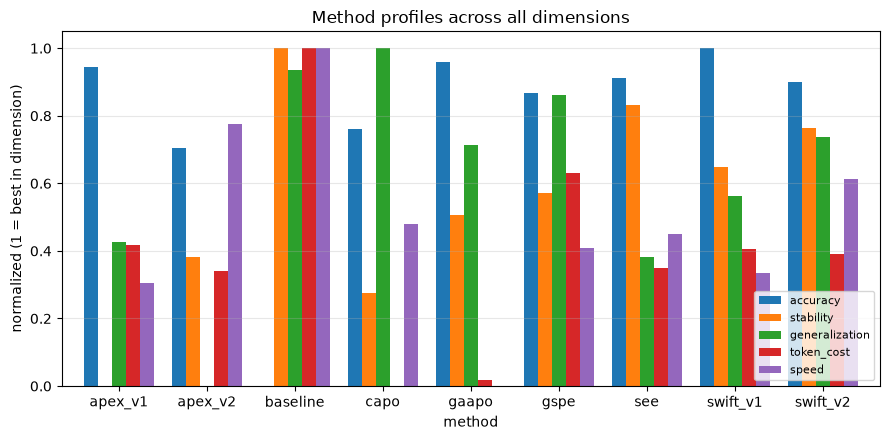

In [12]:
# Normalized profiles: 1.0 = best method on that dimension.
norm = pd.DataFrame(index=dims.index)
rng_ = dims['accuracy'].max() - dims['accuracy'].min() + 1e-12
norm['accuracy'] = (dims['accuracy'] - dims['accuracy'].min()) / rng_
for c in ['stability', 'generalization', 'token_cost', 'speed']:
    rng_ = dims[c].max() - dims[c].min() + 1e-12
    norm[c] = 1 - (dims[c] - dims[c].min()) / rng_

ax = norm.plot(kind='bar', figsize=(9, 4.5), width=0.8)
ax.set_ylabel('normalized (1 = best in dimension)')
ax.set_title('Method profiles across all dimensions')
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 8. Convergence — value added per generation

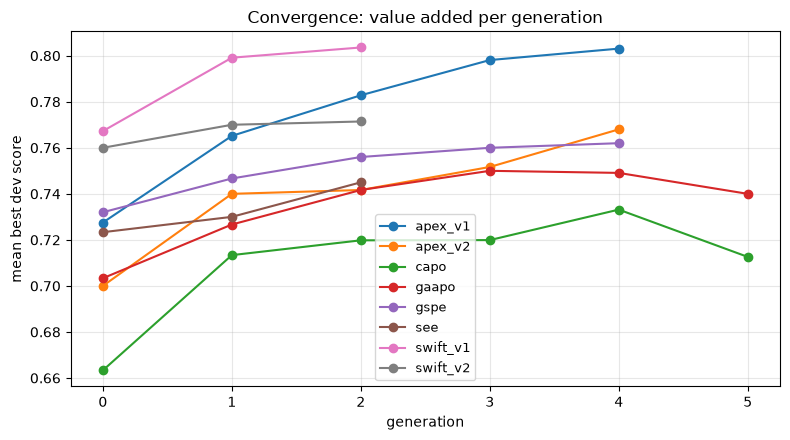

In [13]:
trajs = []
for f in sorted(OUTPUTS.rglob('result_*.json')):
    if f.stat().st_mtime < cutoff_ts:
        continue
    rel = f.relative_to(OUTPUTS).parts
    method = rel[1] if len(rel) == 5 else rel[0]
    d = json.loads(f.read_text(encoding='utf-8'))
    for g in d.get('optimization_history', []):
        trajs.append({'method': method, 'generation': g['generation'],
                      'best_score': g['best_score']})
tdf = pd.DataFrame(trajs)
if len(tdf):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for m, g in tdf.groupby('method'):
        curve = g.groupby('generation')['best_score'].mean()
        ax.plot(curve.index, curve.values, marker='o', label=m)
    ax.set_xlabel('generation'); ax.set_ylabel('mean best dev score')
    ax.set_title('Convergence: value added per generation')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 9. Raw data

In [14]:
df.drop(columns=['empty_prompt']).sort_values(['task', 'method', 'seed']).reset_index(drop=True)

,model,method,task,seed,dev,test,time_s,calls,tokens_in,tokens_out,tokens,iters,mtime
0,default,apex_v1,causal_judgement,7,0.72,0.600000,489.56,496,1084110,16359,1100469,5,2026-07-10 09:06:14.864348
1,default,apex_v1,causal_judgement,42,0.68,0.678261,485.48,706,1176384,18592,1194976,5,2026-07-10 09:06:15.618966
2,default,apex_v1,causal_judgement,123,0.68,0.582609,469.46,621,1151134,16919,1168053,5,2026-07-10 09:06:16.548965
3,default,apex_v2,causal_judgement,7,0.72,0.600000,607.51,512,1557024,21221,1578245,5,2026-07-10 23:42:51.756370
4,default,apex_v2,causal_judgement,42,0.64,0.634783,457.67,374,903560,16724,920284,5,2026-07-10 23:42:52.675458
...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,default,swift_v1,hyperbaton,42,0.92,0.834783,459.25,460,763917,17740,781657,3,2026-07-10 09:06:45.136252
138,default,swift_v1,hyperbaton,123,0.94,0.878261,290.54,369,463071,12438,475509,3,2026-07-10 09:06:46.105975
139,default,swift_v2,hyperbaton,7,0.88,0.843478,435.93,333,739125,18086,757211,3,2026-07-10 23:42:55.438687
140,default,swift_v2,hyperbaton,42,0.88,0.860870,427.07,351,687110,18450,705560,3,2026-07-10 23:42:56.278932
